# RankMe Analysis: AdamW vs. Muon

## Setup

In [1]:
# Clone the repo so this notebook is fully self-contained —
# just download demo.ipynb and run it, no other files needed.
!git clone https://github.com/karpathy/autoresearch.git 2>/dev/null || echo 'Repo already cloned'
%cd autoresearch

Repo already cloned
/workspace/autoresearch


In [2]:
!pip install -q datasets==4.0.0 tokenizers tiktoken matplotlib tqdm huggingface_hub==1.7.1 fsspec==2023.10.0

In [3]:
import os
import gc
import math
import time
from contextlib import nullcontext
from dataclasses import dataclass, asdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

# ---------------------------------------------------------------------------
# GPU Check
# ---------------------------------------------------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name()
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB VRAM)')
else:
    print('WARNING: No GPU found. Training will be extremely slow.')

print(f'PyTorch version: {torch.__version__}')

if device.type == 'cuda':
    autocast_device_type = 'cuda'
    try:
        with torch.amp.autocast(device_type=autocast_device_type, dtype=torch.bfloat16):
            _ = torch.ones(1, device=device) @ torch.ones(1, device=device)
        autocast_dtype = torch.bfloat16
    except RuntimeError:
        autocast_dtype = torch.float16
elif device.type == 'cpu':
    autocast_device_type = 'cpu'
    autocast_dtype = torch.bfloat16
else:
    autocast_device_type = None
    autocast_dtype = None

def autocast_context():
    if autocast_device_type is None or autocast_dtype is None:
        return nullcontext()
    return torch.amp.autocast(device_type=autocast_device_type, dtype=autocast_dtype)

print(f'Autocast dtype: {autocast_dtype}')


GPU: NVIDIA RTX A5000 (23.7 GB VRAM)
PyTorch version: 2.9.1+cu128
Autocast dtype: torch.bfloat16


In [4]:
# =====================================================================
# DATASET & MODEL CONFIGURATION
# Modify these settings before running the rest of the notebook.
# =====================================================================

# --- Dataset ---
# Choose one of: "dclm-edu", "pleias-synth"
DATASET = 'dclm-edu'  # @param ["dclm-edu", "pleias-synth"]

# How many documents to download. These documents are all used for 
# computing the RankMe coefficient, we call this validation for simplicity
NUM_VAL_DOCS = 10_000

# --- Tokenizer ---
# Vocabulary size for our BPE tokenizer.
# Larger vocab = fewer tokens per text (faster training per doc)
# but larger embedding tables (more parameters).
VOCAB_SIZE = 8192

# --- Model Architecture ---
DEPTH = 8               # Number of transformer layers
ASPECT_RATIO = 64       # Hidden dim = DEPTH * ASPECT_RATIO
HEAD_DIM = 64           # Dimension per attention head
MAX_SEQ_LEN = 1024      # Context window length (in tokens)

# --- Training ---
DEVICE_BATCH_SIZE = 32  # Micro-batch size per forward pass (reduce if OOM)

# --- Reproducibility ---
SEED = 42

# --- torch.compile ---
# torch.compile fuses operations for speed, but the first step is slow
# due to compilation. Set to False if you hit compatibility issues.
USE_COMPILE = True


### Prepare dataset

In [5]:
import os
from huggingface_hub import login

# (Optional) Set your HuggingFace token for faster downloads.
# Get a free token at https://huggingface.co/settings/tokens
# Token for higher rate limits & faster download.
HF_TOKEN = None

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("Logged in to HuggingFace Hub")
else:
    print("No HF token set — downloads will work but may be rate-limited.")

# ---

from datasets import load_dataset

total_docs = NUM_VAL_DOCS
all_texts = []

if DATASET == 'dclm-edu':
    # DCLM-edu: educational web text scored by a quality classifier.
    # Each sample has a 'text' field with the document content.
    print('Loading DCLM-edu dataset (educational web text)...')
    files = {
        "train": [
            "hf://datasets/HuggingFaceTB/dclm-edu/data/000_00000.parquet",
            "hf://datasets/HuggingFaceTB/dclm-edu/data/000_00001.parquet",
        ]
    }
    
    ds = load_dataset(
        "parquet",
        data_files=files,
        split="train",
        streaming=False,
        columns=["text", "edu_int_score"],   # keep only what you need
        filters=[("edu_int_score", ">=", 3)] # push down filtering if possible
    )
    for i, example in enumerate(tqdm(ds, total=total_docs, desc='Downloading')):
        if i >= total_docs:
            break
        all_texts.append(example['text'])

elif DATASET == 'pleias-synth':
    # PleIAs/SYNTH: synthetic Q&A data derived from Wikipedia.
    # We concatenate the question, reasoning, and answer into one document.
    print('Loading PleIAs/SYNTH dataset (synthetic Q&A from Wikipedia)...')
    ds = load_dataset('PleIAs/SYNTH', split='train', streaming=True)
    for i, example in enumerate(tqdm(ds, total=total_docs, desc='Downloading')):
        if i >= total_docs:
            break
        parts = []
        if example.get('query'):
            parts.append('Question: ' + example['query'])
        if example.get('synthetic_reasoning'):
            parts.append('Reasoning: ' + example['synthetic_reasoning'])
        if example.get('synthetic_answer'):
            parts.append('Answer: ' + example['synthetic_answer'])
        all_texts.append('\n\n'.join(parts))

else:
    raise ValueError(f'Unknown dataset: {DATASET}')

# Split into train and validation sets
val_texts = all_texts

# Show a sample
avg_len = sum(len(t) for t in val_texts) / len(val_texts)
print(f'Val documents:   {len(val_texts):,}')
print(f'Avg doc length:  {avg_len:.0f} chars')
print(f'\n--- Sample document (first 500 chars) ---')
print(val_texts[0][:500])

No HF token set — downloads will work but may be rate-limited.
Loading DCLM-edu dataset (educational web text)...


Downloading:   0%|          | 0/10000 [00:00<?, ?it/s]

Val documents:   10,000
Avg doc length:  6514 chars

--- Sample document (first 500 chars) ---
Books  Palaeontology  Palaeozoology & Extinctions 


Popular Science

By: WJT Mitchell(Author)

321 pages, Col and b/w photos, col and b/w illus

University of Chicago Press

Hardback | Oct 1998 | #84743 | ISBN: 0226532046
Availability: Usually dispatched within 4 days Details
NHBS Price: £24.50 $32/€27 approx

About this book

For animals that have been dead millions of years, dinosaurs are extraordinarily pervasive in our everyday lives. Appearing in ads, books, movies, museums, television, to


### Load pretrained tokenizer (common to both AdamW and Muon checkpoints)

In [6]:
from tokenizers import Tokenizer as HFTokenizer, models, trainers, pre_tokenizers, decoders

tokenizer_path = "tokenizer.json"

if os.path.exists(tokenizer_path):
    print("Loading existing tokenizer...")
    tok_model = HFTokenizer.from_file(tokenizer_path)
    
    BOS_TOKEN_ID = tok_model.token_to_id('<|bos|>')
    ACTUAL_VOCAB_SIZE = tok_model.get_vocab_size()
    
    print(f'Vocabulary size: {ACTUAL_VOCAB_SIZE}')
    print(f'BOS token ID: {BOS_TOKEN_ID}')
    
    # Sanity check: encode then decode should give back the original text
    test = 'Hello world! Numbers: 42.'
    encoded = tok_model.encode(test)
    decoded = tok_model.decode(encoded.ids)
    print(f'\nSanity check:')
    print(f'  Input:   {test!r}')
    print(f'  Tokens:  {encoded.ids[:20]}... ({len(encoded.ids)} tokens)')
    print(f'  Decoded: {decoded!r}')

Loading existing tokenizer...
Vocabulary size: 8192
BOS token ID: 0

Sanity check:
  Input:   'Hello world! Numbers: 42.'
  Tokens:  [40, 451, 79, 906, 1, 432, 347, 1255, 26, 747, 18, 14]... (12 tokens)
  Decoded: 'Hello world! Numbers: 42.'


### Tokenize dataset

In [7]:
def tokenize_texts(texts, desc='Tokenizing'):
    """Tokenize a list of texts, prepending BOS to each document."""
    all_ids = []
    batch_size = 1000
    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[i:i + batch_size]
        encoded = tok_model.encode_batch(batch)
        for enc in encoded:
            all_ids.append(BOS_TOKEN_ID)
            all_ids.extend(enc.ids)
    return torch.tensor(all_ids, dtype=torch.long)

print('Tokenizing validation data...')
val_data = tokenize_texts(val_texts, desc='Val')

print(f'Val tokens:   {len(val_data):,} ({val_data.nbytes / 1024**2:.1f} MB)')
print(f'Tokens per doc (avg): {len(val_data) / NUM_VAL_DOCS:.0f}')

# Free raw text to save RAM
del all_texts, val_texts
gc.collect()
print('Data preparation complete!')

Tokenizing validation data...


Val:   0%|          | 0/10 [00:00<?, ?it/s]

Val tokens:   17,395,893 (132.7 MB)
Tokens per doc (avg): 1740
Data preparation complete!


### Build dataloader

In [8]:
def make_dataloader(data_tensor, batch_size, seq_len):
    """
    Infinite dataloader that yields random chunks from a flat token tensor.

    For each batch:
      - Sample `batch_size` random starting positions
      - x = data[pos : pos + seq_len]        (input)
      - y = data[pos + 1 : pos + seq_len + 1] (target, shifted by 1)

    This is simpler than the best-fit packing used in the full autoresearch
    code, but works well for learning purposes.
    """
    n = len(data_tensor) - seq_len - 1
    assert n > 0, f'Data too short ({len(data_tensor)} tokens) for seq_len={seq_len}'
    while True:
        # Sample random starting positions
        ix = torch.randint(0, n, (batch_size,))
        # Stack into batches and move to GPU
        x = torch.stack([data_tensor[i:i + seq_len] for i in ix]).to(device)
        y = torch.stack([data_tensor[i + 1:i + seq_len + 1] for i in ix]).to(device)
        yield x, y

# Quick test
_test_loader = make_dataloader(val_data, 2, 8)
_xb, _yb = next(_test_loader)
print(f'Batch shape: x={list(_xb.shape)}, y={list(_yb.shape)}')
print(f'Example x: {_xb[0].tolist()}')
print(f'Example y: {_yb[0].tolist()}')
print(f'(y is x shifted right by 1 position)')
del _test_loader, _xb, _yb

Batch shape: x=[2, 8], y=[2, 8]
Example x: [181, 44, 375, 12, 2566, 12, 337, 1210]
Example y: [44, 375, 12, 2566, 12, 337, 1210, 257]
(y is x shifted right by 1 position)


In [9]:
val_loader = make_dataloader(val_data, DEVICE_BATCH_SIZE, MAX_SEQ_LEN)

### GPT model definition (same as in training notebook)

In [10]:
# ---------------------------------------------------------------------------
# GPT Model Definition
# ---------------------------------------------------------------------------

@dataclass
class GPTConfig:
    """All the hyperparameters that define the model architecture."""
    sequence_len: int = 1024    # Maximum context length
    vocab_size: int = 8192      # Number of tokens in the vocabulary
    n_layer: int = 8            # Number of transformer blocks
    n_head: int = 8             # Number of query attention heads
    n_kv_head: int = 8          # Number of key/value heads (can be < n_head for GQA)
    n_embd: int = 512           # Hidden dimension (embedding size)


def rms_norm(x):
    """
    Root Mean Square Layer Normalization.
    Unlike LayerNorm, RMSNorm does not subtract the mean or use a bias.
    It simply scales by 1/RMS, which is simpler and works well in practice.
    """
    return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + 1e-6)


def has_ve(layer_idx, n_layer):
    """
    Determines if a layer should have Value Embeddings.
    Uses an alternating pattern, with the last layer always included.
    Value Embeddings (from ResFormer) provide a residual connection
    from the input tokens directly to the attention values.
    """
    return layer_idx % 2 == (n_layer - 1) % 2


def apply_rotary_emb(x, cos, sin):
    """
    Apply Rotary Position Embeddings (RoPE).

    RoPE encodes position information by rotating the query and key vectors.
    This allows the model to attend to tokens based on their relative position,
    not just absolute position. The rotation angle depends on the position and
    the dimension, creating a rich positional encoding.

    x shape: [B, num_heads, T, head_dim]
    cos/sin shape: [1, 1, T, head_dim // 2]
    """
    d = x.shape[-1] // 2
    x1, x2 = x[..., :d], x[..., d:]
    y1 = x1 * cos + x2 * sin
    y2 = x1 * (-sin) + x2 * cos
    return torch.cat([y1, y2], -1)


class CausalSelfAttention(nn.Module):
    """
    Multi-Head Causal Self-Attention.

    Each token attends to all previous tokens (and itself) to build
    a contextualized representation. The 'causal' mask ensures tokens
    can only see the past, not the future.

    Supports Grouped Query Attention (GQA) where fewer KV heads are used
    than Q heads, saving memory with minimal quality loss.
    """

    def __init__(self, config, layer_idx):
        super().__init__()
        self.n_head = config.n_head
        self.n_kv_head = config.n_kv_head
        self.n_embd = config.n_embd
        self.head_dim = self.n_embd // self.n_head
        assert self.n_embd % self.n_head == 0
        assert self.n_kv_head <= self.n_head and self.n_head % self.n_kv_head == 0

        # Linear projections for queries, keys, values, and output
        self.c_q = nn.Linear(self.n_embd, self.n_head * self.head_dim, bias=False)
        self.c_k = nn.Linear(self.n_embd, self.n_kv_head * self.head_dim, bias=False)
        self.c_v = nn.Linear(self.n_embd, self.n_kv_head * self.head_dim, bias=False)
        self.c_proj = nn.Linear(self.n_embd, self.n_embd, bias=False)

        # Value Embedding gate (ResFormer): mixes token-level value embeddings
        # into the attention values with an input-dependent gate per head
        self.ve_gate_channels = min(32, self.n_embd)
        self.ve_gate = (
            nn.Linear(self.ve_gate_channels, self.n_kv_head, bias=False)
            if has_ve(layer_idx, config.n_layer) else None
        )

    def forward(self, x, ve, cos_sin):
        B, T, C = x.size()

        # Project input to queries, keys, and values
        # Then reshape to [B, num_heads, T, head_dim] for attention
        q = self.c_q(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.c_k(x).view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)
        v = self.c_v(x).view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)

        # Value residual (ResFormer): add token-level value embeddings
        # with a learned input-dependent gate. This provides a shortcut
        # from the input tokens to deeper layers.
        if ve is not None and self.ve_gate is not None:
            ve_reshaped = ve.view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)
            gate = 2 * torch.sigmoid(self.ve_gate(x[..., :self.ve_gate_channels]))
            gate = gate.transpose(1, 2).unsqueeze(-1)  # [B, n_kv_head, T, 1]
            v = v + gate * ve_reshaped

        # Apply rotary position embeddings to Q and K
        cos, sin = cos_sin
        q = apply_rotary_emb(q, cos, sin)
        k = apply_rotary_emb(k, cos, sin)

        # QK-Norm: normalize Q and K for training stability
        q, k = rms_norm(q), rms_norm(k)

        # Grouped Query Attention: expand KV heads to match Q heads
        if self.n_kv_head < self.n_head:
            repeat = self.n_head // self.n_kv_head
            k = k.repeat_interleave(repeat, dim=1)
            v = v.repeat_interleave(repeat, dim=1)

        # Scaled dot-product attention with causal mask
        # This replaces Flash Attention 3 from the original code,
        # making it compatible with any GPU.
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)

        # Reshape back to [B, T, C] and project output
        y = y.transpose(1, 2).contiguous().view(B, T, -1)
        y = self.c_proj(y)
        return y


class MLP(nn.Module):
    """
    Feed-Forward Network (MLP) with ReLU-squared activation.

    The hidden dimension is 4x the model dimension, following the
    standard transformer convention. ReLU^2 (squared ReLU) provides
    sparsity while being smooth, which can improve training.
    """

    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=False)
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=False)

    def forward(self, x):
        x = self.c_fc(x)
        x = F.relu(x).square()   # Squared ReLU activation
        x = self.c_proj(x)
        return x


class Block(nn.Module):
    """
    A single Transformer block: Attention + MLP with residual connections.

    The pre-norm architecture applies RMS normalization BEFORE each sub-layer,
    which is more stable for training than post-norm.
    """

    def __init__(self, config, layer_idx):
        super().__init__()
        self.attn = CausalSelfAttention(config, layer_idx)
        self.mlp = MLP(config)

    def forward(self, x, ve, cos_sin):
        # Pre-norm + attention + residual
        x = x + self.attn(rms_norm(x), ve, cos_sin)
        # Pre-norm + MLP + residual
        x = x + self.mlp(rms_norm(x))
        return x


class GPT(nn.Module):
    """
    The complete GPT model.

    Architecture highlights:
    - Token embeddings (wte) convert token IDs to vectors
    - Rotary position embeddings encode position via rotation
    - Per-layer residual scaling (resid_lambdas, x0_lambdas) from the
      'shortGPT' and 'ResFormer' papers improve deep network training
    - Value embeddings provide direct token-to-attention-value shortcuts
    - Logit soft-capping prevents extreme logit values
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict({
            'wte': nn.Embedding(config.vocab_size, config.n_embd),
            'h': nn.ModuleList([Block(config, i) for i in range(config.n_layer)]),
        })
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Per-layer residual scaling factors
        # x_new = resid_lambda * x + x0_lambda * x0  (before each block)
        # where x0 is the initial embedding. This helps gradient flow.
        self.resid_lambdas = nn.Parameter(torch.ones(config.n_layer))
        self.x0_lambdas = nn.Parameter(torch.zeros(config.n_layer))

        # Value embeddings: direct token-to-value shortcuts for select layers
        head_dim = config.n_embd // config.n_head
        kv_dim = config.n_kv_head * head_dim
        self.value_embeds = nn.ModuleDict({
            str(i): nn.Embedding(config.vocab_size, kv_dim)
            for i in range(config.n_layer) if has_ve(i, config.n_layer)
        })

        # Precompute rotary embeddings
        cos, sin = self._precompute_rotary(config.sequence_len, head_dim)
        self.register_buffer('cos', cos, persistent=False)
        self.register_buffer('sin', sin, persistent=False)

    def _precompute_rotary(self, seq_len, head_dim, base=10000):
        """Precompute cos/sin tables for RoPE."""
        inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
        t = torch.arange(seq_len, dtype=torch.float32)
        freqs = torch.outer(t, inv_freq)
        cos = freqs.cos()[None, None, :, :]   # [1, 1, T, head_dim//2]
        sin = freqs.sin()[None, None, :, :]
        return cos, sin

    @torch.no_grad()
    def init_weights(self):
        """Custom weight initialization for stable training."""
        n_embd = self.config.n_embd
        s = 3**0.5 * n_embd**-0.5   # Scale for uniform init

        # Embedding: normal init with std=1.0
        nn.init.normal_(self.transformer.wte.weight, mean=0.0, std=1.0)
        # LM head: very small init for stable early training
        nn.init.normal_(self.lm_head.weight, mean=0.0, std=0.001)

        for block in self.transformer.h:
            nn.init.uniform_(block.attn.c_q.weight, -s, s)
            nn.init.uniform_(block.attn.c_k.weight, -s, s)
            nn.init.uniform_(block.attn.c_v.weight, -s, s)
            nn.init.zeros_(block.attn.c_proj.weight)    # Zero init for residual
            nn.init.uniform_(block.mlp.c_fc.weight, -s, s)
            nn.init.zeros_(block.mlp.c_proj.weight)     # Zero init for residual

        self.resid_lambdas.fill_(1.0)
        self.x0_lambdas.fill_(0.1)

        for ve in self.value_embeds.values():
            nn.init.uniform_(ve.weight, -s, s)
        for block in self.transformer.h:
            if block.attn.ve_gate is not None:
                nn.init.zeros_(block.attn.ve_gate.weight)

    def forward(self, idx, targets=None, reduction='mean', return_features=False):
        """
        Forward pass.

        Args:
            idx: Token IDs, shape [B, T]
            targets: Target token IDs, shape [B, T] (for computing loss)
            reduction: 'mean' for scalar loss, 'none' for per-token loss

        Returns:
            Loss (if targets given) or logits [B, T, vocab_size]
        """
        B, T = idx.size()
        cos_sin = self.cos[:, :, :T, :], self.sin[:, :, :T, :]

        # Token embedding + normalization
        x = self.transformer.wte(idx)
        x = rms_norm(x)
        x0 = x  # Save for residual shortcut

        # Pass through transformer blocks
        for i, block in enumerate(self.transformer.h):
            # Per-layer residual scaling
            x = self.resid_lambdas[i] * x + self.x0_lambdas[i] * x0
            # Value embeddings (only for select layers)
            ve = self.value_embeds[str(i)](idx) if str(i) in self.value_embeds else None
            x = block(x, ve, cos_sin)

        x = rms_norm(x)
        if return_features:
            return x
        # Project to vocabulary with soft-capping
        # Soft-capping prevents extreme logit values, improving training stability
        softcap = 15
        logits = self.lm_head(x).float()
        logits = softcap * torch.tanh(logits / softcap)

        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
                reduction=reduction,
            )
            return loss
        return logits

    def estimate_flops(self):
        """Estimate FLOPs per token (forward + backward)."""
        nparams = sum(p.numel() for p in self.parameters())
        ve_numel = sum(ve.weight.numel() for ve in self.value_embeds.values())
        nparams_ex = (
            self.transformer.wte.weight.numel() + ve_numel
            + self.resid_lambdas.numel() + self.x0_lambdas.numel()
        )
        h = self.config.n_head
        q = self.config.n_embd // self.config.n_head
        t = self.config.sequence_len
        attn_flops = self.config.n_layer * 12 * h * q * t
        return 6 * (nparams - nparams_ex) + attn_flops

print('Model definition loaded.')

Model definition loaded.


### Initialize model

In [11]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.set_float32_matmul_precision('high')  # Use TF32 for faster matmuls

# Compute model dimensions
base_dim = DEPTH * ASPECT_RATIO
model_dim = ((base_dim + HEAD_DIM - 1) // HEAD_DIM) * HEAD_DIM
num_heads = model_dim // HEAD_DIM

config = GPTConfig(
    sequence_len=MAX_SEQ_LEN,
    vocab_size=ACTUAL_VOCAB_SIZE,
    n_layer=DEPTH,
    n_head=num_heads,
    n_kv_head=num_heads,
    n_embd=model_dim,
)
print(f'Model config: {asdict(config)}')

model = GPT(config).to(device)

if USE_COMPILE and hasattr(torch, 'compile'):
    print('\nCompiling model with torch.compile (first step will be slow)...')
    model = torch.compile(model)


Model config: {'sequence_len': 1024, 'vocab_size': 8192, 'n_layer': 8, 'n_head': 8, 'n_kv_head': 8, 'n_embd': 512}

Compiling model with torch.compile (first step will be slow)...


# RankMe Analysis

In [12]:
def compute_spectral_metrics(tensor):
    """
    Compute spectral metrics on collected activations.
    We compute: RankMe, Participation Ratio (PR), AlphaReQ, and Top-K Variance. 
    All of these are based on the eigenvalues of the covariance matrix of the activations.
    Computation on GPU for efficiency.
    """
    N, D = tensor.shape
    if N < 2:
        return {"rankme": 0.0, "pr": 0.0, "alpha_req": 0.0, **{f"top_{k}_var": 0.0 for k in TOP_K_VALS}}

    try:
        centered = tensor.to(device).to(torch.float64)
        centered = centered - centered.mean(dim=0, keepdim=True)

        if N <= D:
            mat = torch.mm(centered, centered.t())
        else:
            mat = torch.mm(centered.t(), centered)

        eigvals = torch.linalg.eigvalsh(mat)
        eigvals = torch.flip(eigvals, dims=[0])
        eigvals = torch.clamp(eigvals, min=0.0)

        total = eigvals.sum() + 1e-12
        p = eigvals / total
        p_safe = p[p > 1e-12]
        rankme = torch.exp(-(p_safe * torch.log(p_safe)).sum()).item()

        pr = (total ** 2 / ((eigvals ** 2).sum() + 1e-12)).item()

        s = eigvals.sqrt()
        valid = s > 1e-6
        if valid.sum() > 2:
            s_v = s[valid]
            ranks = torch.arange(1, len(s_v) + 1, dtype=torch.float64, device=device)
            x = torch.log(ranks)
            y = torch.log(s_v)
            xm, ym = x.mean(), y.mean()
            slope = ((x - xm) * (y - ym)).sum() / (((x - xm) ** 2).sum() + 1e-12)
            alpha_req = -slope.item()
        else:
            alpha_req = 0.0


    except Exception as e:
        print(f"Spectral computation failed: {e}")
        return {"rankme": 1.0, "pr": 1.0, "alpha_req": 0.0}

    return {
        "rankme": round(rankme, 4),
        "pr": round(pr, 4),
        "alpha_req": round(alpha_req, 6)
    }


@torch.no_grad()
def colelct_matrix(model, N):
    """
    Build the matrix of shape [N, D] where N=num_embeddings, D=embd. dimension.
    Each embedding is extracted from the last layer, last token.
    """
    model.eval()
    final_feats = []
    num_batches = N //DEVICE_BATCH_SIZE + 1
    for _ in range(num_batches):
        x, _ = next(val_loader)
        with autocast_context():
            feats = model(x, return_features=True)
        last = feats[:, -1].detach().to(torch.float32).cpu()
        del feats                      # free the [B,T,D] tensor before next iter
        final_feats.append(last)
    final_feats = torch.cat(final_feats, dim=0)
    
    return final_feats[:N, :] # [N, D]

Skipping Adam: checkpoint directory not found: ./checkpoints/adam
RankMe calculation for Muon: ./checkpoints/muon/model_step_12600.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_12250.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_11900.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_11550.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_11200.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_10850.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_10500.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_10150.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_9800.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_9450.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_step_9100.safetensors...
RankMe calculation for Muon: ./checkpoints/muon/model_ste

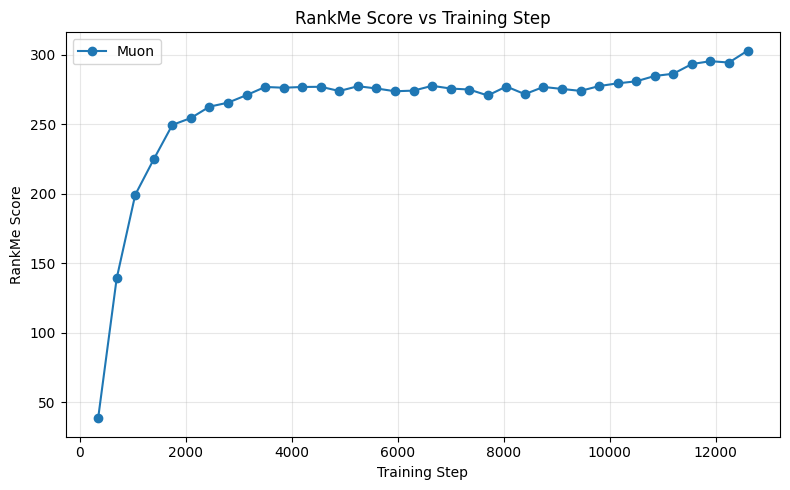

In [14]:
import os
import re
import gc
import matplotlib.pyplot as plt
from safetensors.torch import load_file


def extract_step(filename):
    match = re.search(r"step_(\d+)", filename)
    return int(match.group(1)) if match else None


OPTIMIZER_CKPTS = {
    "AdamW": "./checkpoints/adamw",
    "Adam": "./checkpoints/adam",
    "Muon": "./checkpoints/muon",
    "SGD": "./checkpoints/sgd",
    "AdEMAMix": "./checkpoints/ademamix",
}

N = 2000

rankme_results = {}

for optimizer_label, ckpt_dir in OPTIMIZER_CKPTS.items():
    data = []

    if not os.path.isdir(ckpt_dir):
        print(f"Skipping {optimizer_label}: checkpoint directory not found: {ckpt_dir}")
        rankme_results[optimizer_label] = data
        continue

    filenames = [
        f for f in os.listdir(ckpt_dir)
        if os.path.isfile(os.path.join(ckpt_dir, f)) and f.endswith(".safetensors")
    ]

    for filename in filenames:
        step = extract_step(filename)
        if step is None:
            continue

        filepath = os.path.join(ckpt_dir, filename)
        print(f"RankMe calculation for {optimizer_label}: {filepath}...")

        state_dict = load_file(filepath)
        model.load_state_dict(state_dict)

        tensor = colelct_matrix(model, N)
        metrics = compute_spectral_metrics(tensor)
        data.append((step, metrics))

        del state_dict
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

    data.sort(key=lambda x: x[0])
    rankme_results[optimizer_label] = data


# --- Plot ---
plt.figure(figsize=(8, 5))

for optimizer_label, data in rankme_results.items():
    if not data:
        continue

    steps, metrics = zip(*data)
    rankme_vals = [m["rankme"] for m in metrics]
    plt.plot(steps, rankme_vals, label=optimizer_label, marker="o")

plt.xlabel("Training Step")
plt.ylabel("RankMe Score")
plt.title("RankMe Score vs Training Step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()